## Подробное описание эксперимента

Эксперимент моделирует процесс радиолокационного измерения с использованием двух типов последовательностей длины 32: многочлен Шапиро и случайная последовательность. Цель эксперимента — показать, как разные последовательности влияют на точность обнаружения целей в условиях шумного канала и ограниченного числа импульсов.

Ниже описываются те параметры, которые использовались в эксперименте. Все приведённые параметры можно изменять и моделировать другой эксперимент. 

### Настройка параметров и их расчёт

1. Файлы с последовательностями
   - *shapiro_polynomial_for_radar_experiment.txt*: файл с коэффициентами многочлена Шапиро. Обладает свойствами низкой корреляции между сдвигами, что улучшает обнаружение целей.
   - *random_polynomial_for_radar_experiment.txt*: файл со случайной последовательностью для сравнения эффективности.

2. Параметры сигнала
   - *fs* = 50e6 Гц — частота дискретизации.
   - *n_pulses* = 2 — количество импульсов. В экперименте происходит два испускания сигнала.
   - *PRI_ms* = 0.0008 — Pulse Repetition Interval(период повторения импульсов). Первый импульс просходит в момент времени t = 0, второй через 0.0008 мс

3. Моделирование целей

   В эксперименте моделируются 3 цели, которые должны быть обнаружены за счёт получения отражённого сигнала.

   - *targets_ms* = [0.002, 0.005, 0.008] — временные задержки эхо-сигналов от каждой цели, рассчитываются исходя из расстояния до цели и скорости распространения сигнала: $delay_{ms} = \frac{2 \cdot distance_m}{c} \cdot 1000$.

   - *targets_amp* = [0.9, 0.9, 0.9] — коэффициенты амплитуды отражённых сигналов. Эти значения масштабируют элементы последовательности 1 и -1, формируя отражённый сигнал; амплитуды напрямую влияют на абсолютное значение корреляции при matched-filter и на достижение порога *threshold_abs*, определяя, насколько заметен сигнал каждой цели в расчетах.

   **Примечание о matched-filter:** Matched-filter — это согласованный фильтр, который используется для обнаружения известного сигнала в зашумлённом приёмном сигнале. Он вычисляет корреляцию между полученным сигналом и эталонной последовательностью (например, переданной последовательностью ±1), максимизируя отношение сигнал/шум. Пики на выходе фильтра соответствуют моментам времени прихода отражённых сигналов от целей. Благодаря matched-filter производится расчет абсолютного значения корреляции, что позволяет определить, превышает ли сигнал порог *threshold_abs*, и, соответственно, была ли цель обнаружена.




4. Шум и порог детекции

   - *noise_std* = 1 — стандартное отклонение гауссовского шума.
   - *threshold_rel* = 0.42 — относительный порог детекции (вычислен в результате большого эксперимента, подробно описан ниже).
   - *threshold_abs* — значения выше этого порога распознаются детектером
   - *tol_ms* — допуск на совпадение пика с ожидаемым временем прихода отражённого сигнала. Он учитывает погрешности, которые возникают из-за дискретизации, шума и небольших вариаций сигналов от разных импульсов. Если tol_ms не задан, он автоматически выбирается по формуле:
   $tol_{ms} = min(\frac{pulse_{duration}}{4}, \frac{PRI_{ms}}{3}, 0.00005)$.
   Этот параметр задаёт допустимое временное окно, в пределах которого пиковое значение корреляции считается совпадением с ожидаемым временем цели. Пик не обязательно должен совпадать точно с олжидаемым временем; достаточно, чтобы он находился в пределах tol_ms, чтобы он был засчитан как обнаружение цели.
   - *x_window_ms* = 0.012 — окно визуализации, используемое при построении графиков корреляции.





In [112]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import correlate
import pandas as pd
from scipy.stats import norm
from typing import List, Optional, Dict, Any
import tqdm
import os


In [113]:
class Sequence:
    """
    Класс Sequence предназначен для представления и генерации последовательностей ±1, 
    используемых в радиолокационных экспериментах и цифровой обработке сигналов.
    
    Последовательность может быть:
    - Загружена из файла (например, коэффициенты многочлена Шапиро или случайной последовательности).
    - Сгенерирована случайным образом с контролируемым seed генератора для воспроизводимости.
    
    Атрибуты:
        seq (np.ndarray[float]): массив чисел ±1, представляющий последовательность.
        N (int): длина последовательности.
    
    Используется как базовая структура для формирования передающего сигнала в эксперименте.
    
    Пример использования:
        # Создание случайной последовательности длиной 8 с заданным seed
        seq1 = Sequence(length=8, seed=42)
        print(seq1.seq)  # Например: [ 1. -1.  1.  1. -1. -1.  1. -1.]
        print(seq1.N)    # 8

        # Загрузка последовательности из файла
        seq2 = Sequence(filename="path/to/file.txt")
        print(seq2.seq)  # Массив значений из файла, преобразованных в ±1
        print(seq2.N)    # Длина загруженной последовательности
    """
    
    def __init__(self, filename: str | None = None, length: int = 64, seed: int = 0) -> None:
        """
        Инициализация последовательности.
        
        Параметры:
            filename (str | None): путь к файлу с последовательностью. 
                                   Если файл существует, последовательность загружается из него.
            length (int): длина случайной последовательности, если файл не указан.
            seed (int): seed для генератора случайных чисел, чтобы последовательность была воспроизводимой.
        
        Возвращает:
            None: конструктор инициализирует атрибуты seq и N.
        """
        # Если указан файл и он существует, загружаем последовательность из файла
        if filename and os.path.exists(filename):
            s = np.loadtxt(filename, dtype=float)
            # Если последовательность состоит из 0 и 1, преобразуем в -1 и 1
            if np.min(s) == 0 and np.max(s) == 1:
                s = 2*s - 1
            self.seq: np.ndarray = s.astype(float)
        else:
            # Генерация случайной последовательности ±1 с контролируемым seed
            rng = np.random.default_rng(seed)
            self.seq: np.ndarray = (2*rng.integers(0, 2, size=length) - 1).astype(float)
        
        # Сохраняем длину последовательности
        self.N: int = len(self.seq)

In [114]:
class Transmitter:
    """
    Класс Transmitter предназначен для формирования передающего сигнала на основе заданной последовательности ±1.
    
    Реализует многократную генерацию импульсов с заданной периодичностью (PRI) и частотой дискретизации.
    Каждый импульс — это исходная последовательность seq, возможно с интервалами между ними.
    
    Атрибуты:
        seq (np.ndarray[float]): последовательность, которая будет использоваться для формирования импульса.
        n_pulses (int): количество повторений импульса (число передаваемых импульсов).
        PRI_ms (float): период повторения импульсов в миллисекундах (Pulse Repetition Interval).
        fs (float): частота дискретизации сигнала в Гц.
    
    Методы:
        generate_tx() -> Tuple[np.ndarray, List[int], List[float], float]:
            Генерирует сигнал передачи с повторяющимися импульсами.
            Возвращает сигнал, список стартовых индексов импульсов, список стартовых времен в мс и длительность одного импульса в мс.
    
    Пример использования:
        seq_array = np.array([1, -1, 1, 1, -1])
        tx = Transmitter(seq_array, n_pulses=3, PRI_ms=0.5, fs=1e3)
        signal, start_idx, start_times, pulse_dur = tx.generate_tx()
        print(signal)         # Выведет массив с повторяющимися импульсами
        print(start_idx)      # Стартовые индексы каждого импульса
        print(start_times)    # Стартовые времена в мс
        print(pulse_dur)      # Длительность одного импульса в мс
    """
    
    def __init__(self, seq: np.ndarray | list, n_pulses: int, PRI_ms: float, fs: float) -> None:
        """
        Инициализация объекта Transmitter.
        
        Параметры:
            seq (np.ndarray | list): последовательность ±1, формирующая один импульс.
            n_pulses (int): количество повторений импульса.
            PRI_ms (float): период повторения импульсов в миллисекундах.
            fs (float): частота дискретизации сигнала в Гц.
        
        Возвращает:
            None
        """
        self.seq: np.ndarray = np.asarray(seq)
        self.n_pulses: int = int(n_pulses)
        self.PRI_ms: float = float(PRI_ms)
        self.fs: float = fs

    def generate_tx(self) -> Tuple[np.ndarray, List[int], List[float], float]:
        """
        Генерация передающего сигнала с повторяющимися импульсами.
        
        Алгоритм:
            1. Вычисляется количество сэмплов в одном импульсе.
            2. Вычисляется количество сэмплов между импульсами (gap) по PRI.
            3. Формируется общий массив для всех импульсов.
            4. Каждый импульс вставляется в соответствующую позицию.
            5. Формируются списки стартовых сэмплов и стартовых времен в мс.
            6. Вычисляется длительность одного импульса в мс.
        
        Возвращает:
            tx (np.ndarray): массив передающего сигнала.
            start_samples (List[int]): список стартовых индексов каждого импульса.
            start_times_ms (List[float]): список стартовых времен каждого импульса в миллисекундах.
            pulse_duration_ms (float): длительность одного импульса в миллисекундах.
        """
        pulse_samples: int = len(self.seq)
        gap_samples: int = int(round(self.PRI_ms * self.fs / 1000.0))
        if gap_samples < 0:
            gap_samples = 0
        
        total_samples_per_cycle: int = pulse_samples + gap_samples
        total_length: int = self.n_pulses * total_samples_per_cycle
        tx: np.ndarray = np.zeros(total_length)
        
        start_samples: List[int] = []
        start_times_ms: List[float] = []
        
        for k in range(self.n_pulses):
            start: int = k * total_samples_per_cycle
            tx[start:start + pulse_samples] = self.seq
            start_samples.append(start)
            start_times_ms.append(start / self.fs * 1000.0)
        
        pulse_duration_ms: float = pulse_samples / self.fs * 1000.0
        
        return tx, start_samples, start_times_ms, pulse_duration_ms

In [115]:
class Channel:
    """
    Класс Channel моделирует канал передачи сигнала в радиолокационных экспериментах.
    
    Реализует:
    - Формирование чистого эхо-сигнала с задержками и амплитудами для нескольких целей.
    - Добавление шумов к сигналу (общий гауссовский шум).
    
    Атрибуты:
        fs (float): частота дискретизации сигнала в Гц.
        rng (np.random.Generator): генератор случайных чисел для воспроизводимости шумов.
    
    Методы:
        build_echo_clean(tx_signal, delays_ms, amplitudes) -> Tuple[np.ndarray, List[int]]:
            Строит чистый эхо-сигнал для заданного передающего сигнала.
        add_shared_noise(length, noise_std, seed=None) -> np.ndarray:
            Добавляет общий гауссовский шум к сигналу.
    
    Пример использования:
        chan = Channel(fs=1e3, seed=42)
        tx_signal = np.array([1, -1, 1, 1, -1])
        delays = [2.0, 5.0]          # задержки в мс
        amplitudes = [1.0, 0.5]      # амплитуды целей
        echo, expected = chan.build_echo_clean(tx_signal, delays, amplitudes)
        print(echo)                  # Чистый эхо-сигнал
        print(expected)              # Список ожидаемых стартовых сэмплов каждой цели
        noise = chan.add_shared_noise(len(echo), noise_std=0.1)
        signal_with_noise = echo + noise
    """

    def __init__(self, fs: float, seed: int = 0) -> None:
        """
        Инициализация объекта Channel.
        
        Параметры:
            fs (float): частота дискретизации сигнала в Гц.
            seed (int, optional): seed генератора случайных чисел для воспроизводимости шумов.
        
        Возвращает:
            None
        """
        self.fs: float = fs
        self.rng: np.random.Generator = np.random.default_rng(seed)

    def build_echo_clean(self, tx_signal: np.ndarray, delays_ms: List[float], amplitudes: List[float]) -> Tuple[np.ndarray, List[int]]:
        """
        Формирование чистого эхо-сигнала.
        
        Алгоритм:
            1. Определяет длину сигнала и максимальную задержку в сэмплах.
            2. Создаёт массив для результирующего эхо-сигнала.
            3. Находит все стартовые позиции импульсов в tx_signal.
            4. Для каждой цели с задержкой и амплитудой формирует задержанный сигнал и суммирует его.
            5. Формирует список ожидаемых стартовых сэмплов всех целей.
        
        Параметры:
            tx_signal (np.ndarray): передающий сигнал.
            delays_ms (List[float]): список задержек каждой цели в миллисекундах.
            amplitudes (List[float]): амплитуды каждой цели.
        
        Возвращает:
            echo (np.ndarray): массив чистого эхо-сигнала.
            expected_pos_samples (List[int]): список индексов начала каждого эхо-импульса.
        """
        total_len: int = len(tx_signal)
        max_delay_samples: int = int(round(max(delays_ms) * self.fs / 1000.0))
        echo_len: int = total_len + max_delay_samples + 10
        echo: np.ndarray = np.zeros(echo_len)

        # Находим индексы ненулевых элементов исходного сигнала
        nonzero_idx: np.ndarray = np.where(tx_signal != 0)[0]
        if len(nonzero_idx) == 0:
            starts: List[int] = [0]
        else:
            diffs: np.ndarray = np.diff(nonzero_idx)
            breaks: np.ndarray = np.where(diffs > 1)[0]
            starts: List[int] = list(nonzero_idx[np.insert(breaks + 1, 0, 0)])

        expected_pos_samples: List[int] = []
        for d_ms, amp in zip(delays_ms, amplitudes):
            d_s: int = int(round(d_ms * self.fs / 1000.0))
            delayed: np.ndarray = np.zeros(echo_len)
            delayed[d_s:d_s + total_len] = tx_signal
            echo += amp * delayed
            for s in starts:
                expected_pos_samples.append(s + d_s)

        expected_pos_samples = sorted(expected_pos_samples)
        return echo, expected_pos_samples

    def add_shared_noise(self, length: int, noise_std: float, seed: int | None = None) -> np.ndarray:
        """
        Добавление общего гауссовского шума.
        
        Параметры:
            length (int): длина создаваемого шума.
            noise_std (float): стандартное отклонение шума.
            seed (int | None, optional): seed генератора случайных чисел. 
                                         Если None, используется случайное.
        
        Возвращает:
            np.ndarray: массив гауссовского шума длины length.
        """
        if noise_std == 0:
            return np.zeros(length)
        rng: np.random.Generator = np.random.default_rng(seed)
        return rng.normal(0.0, noise_std, size=length)

In [116]:
class Receiver:
    """
    Класс Receiver предназначен для обработки принимаемого сигнала и поиска отражений целей.
    
    Реализует:
    - Математически корректное matched-filter (корреляция) с опорным сигналом.
    - Выделение пиков в корреляционной функции по заданному порогу.
    
    Атрибуты:
        ref (np.ndarray[float]): опорная последовательность для matched-filter.
        fs (float): частота дискретизации сигнала в Гц.
    
    Методы:
        matched_filter_abs(recv_signal) -> Tuple[np.ndarray, np.ndarray]:
            Вычисляет абсолютное значение корреляции сигнала с опорным.
        find_peaks_by_threshold(lags_ms, corr_abs, threshold_abs) -> Tuple[np.ndarray, np.ndarray, List[Tuple[int,int]]]:
            Находит пики корреляции выше заданного порога.
    
    Пример использования:
        ref_signal = np.array([1, -1, 1, 1, -1])
        recv_signal = np.array([0, 1, -1, 1, 1, -1, 0])
        receiver = Receiver(ref_signal, fs=1e3)
        
        lags_ms, corr_abs = receiver.matched_filter_abs(recv_signal)
        peaks_time, peaks_val, segments = receiver.find_peaks_by_threshold(lags_ms, corr_abs, threshold_abs=2.0)
        print(peaks_time)  # Время обнаруженных пиков в мс
        print(peaks_val)   # Значения корреляции пиков
        print(segments)    # Индексы блоков, где обнаружены пики
    """

    def __init__(self, ref: np.ndarray | list, fs: float) -> None:
        """
        Инициализация объекта Receiver.
        
        Параметры:
            ref (np.ndarray | list): опорная последовательность для matched-filter.
            fs (float): частота дискретизации сигнала в Гц.
        
        Возвращает:
            None
        """
        self.ref: np.ndarray = np.asarray(ref)
        self.fs: float = fs

    def matched_filter_abs(self, recv_signal: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
        """
        Применение matched-filter и получение абсолютного значения корреляции.
        
        Параметры:
            recv_signal (np.ndarray): принимаемый сигнал.
        
        Возвращает:
            lags_ms (np.ndarray): массив задержек в миллисекундах, соответствующих корреляции.
            corr_abs (np.ndarray): абсолютное значение корреляционной функции.
        """
        corr: np.ndarray = correlate(recv_signal, self.ref, mode='full')
        corr_abs: np.ndarray = np.abs(corr)
        lags: np.ndarray = np.arange(-len(self.ref) + 1, len(recv_signal))
        lags_ms: np.ndarray = lags / self.fs * 1000.0
        return lags_ms, corr_abs

    def find_peaks_by_threshold(
        self, 
        lags_ms: np.ndarray, 
        corr_abs: np.ndarray, 
        threshold_abs: float
    ) -> Tuple[np.ndarray, np.ndarray, List[Tuple[int,int]]]:
        """
        Поиск пиков в корреляционной функции, превышающих заданный порог.
        
        Алгоритм:
            1. Отбрасывает отрицательные значения задержки.
            2. Находит все значения корреляции выше threshold_abs.
            3. Разделяет последовательность индексов на блоки, где значения подряд выше порога.
            4. Для каждого блока выбирает максимальный пик.
        
        Параметры:
            lags_ms (np.ndarray): массив задержек в миллисекундах.
            corr_abs (np.ndarray): абсолютное значение корреляционной функции.
            threshold_abs (float): порог для обнаружения пиков.
        
        Возвращает:
            peak_times (np.ndarray): массив времен пиков в миллисекундах.
            peak_vals (np.ndarray): значения корреляции в этих пиках.
            segments (List[Tuple[int,int]]): список кортежей (start_idx, end_idx) блоков, где найдены пики.
        """
        mask: np.ndarray = lags_ms >= 0
        lags_probe: np.ndarray = lags_ms[mask]
        corr_probe: np.ndarray = corr_abs[mask]

        above: np.ndarray = corr_probe >= threshold_abs
        if not np.any(above):
            return np.array([]), np.array([]), []

        idx: np.ndarray = np.nonzero(above)[0]
        gaps: np.ndarray = np.where(np.diff(idx) > 1)[0]
        blocks: List[Tuple[int,int]] = []
        start: int = idx[0]
        for g in gaps:
            end_idx: int = idx[g]
            blocks.append((start, end_idx))
            start = idx[g + 1]
        blocks.append((start, idx[-1]))

        peak_times: List[float] = []
        peak_vals: List[float] = []
        segments: List[Tuple[int,int]] = []
        for s, e in blocks:
            sub: np.ndarray = corr_probe[s:e+1]
            i_rel: int = int(np.argmax(sub))
            i_abs: int = s + i_rel
            peak_times.append(float(lags_probe[i_abs]))
            peak_vals.append(float(corr_probe[i_abs]))
            segments.append((int(s), int(e)))

        return np.array(peak_times), np.array(peak_vals), segments


In [117]:
class Experiment:
    """
    Класс Experiment моделирует полный радиолокационный эксперимент с использованием
    последовательностей Шапиро и случайных последовательностей.

    Реализует:
    - Генерацию передающих сигналов для каждой последовательности (Shapiro и Random).
    - Моделирование канала с задержками целей и шумом.
    - Приём сигналов с помощью matched-filter и поиск пиков.
    - Сравнение эффективности детекции сигналов Шапиро и случайных последовательностей.
    - Формирование сводной таблицы результатов и визуализацию.

    Атрибуты:
        fs (float): частота дискретизации в Гц.
        n_pulses (int): количество повторений импульса.
        PRI_ms (float): период повторения импульсов в мс.
        targets_ms (List[float]): список задержек целей в мс.
        targets_amp (List[float]): амплитуды целей.
        noise_std (float): стандартное отклонение шума.
        threshold_rel (float): порог обнаружения как доля от теоретического максимума.
        x_window_ms (float): окно визуализации в мс.
        tol_ms (Optional[float]): допуск при классификации пиков; если None — подбирается автоматически.
        seed (int): зерно генератора случайных чисел для воспроизводимости.
        sh (np.ndarray): последовательность Шапиро.
        rn (np.ndarray): случайная последовательность.
        tx_sh (Transmitter): объект передатчика для последовательности Шапиро.
        tx_rn (Transmitter): объект передатчика для случайной последовательности.
        channel (Channel): объект канала.
        recv_sh (Receiver): объект приёмника для последовательности Шапиро.
        recv_rn (Receiver): объект приёмника для случайной последовательности.
    """

    def __init__(self,
                 sh_file: Optional[str] = None,
                 rn_file: Optional[str] = None,
                 fs: float = 50e6,
                 n_pulses: int = 5,
                 PRI_ms: float = 0.0008,
                 targets_ms: Optional[List[float]] = None,
                 targets_amp: Optional[List[float]] = None,
                 noise_std: float = 0.4,
                 threshold_rel: float = 0.25,
                 x_window_ms: float = 0.016,
                 tol_ms: Optional[float] = None,
                 seed: int = 12345) -> None:
        """
        Инициализация эксперимента.

        Параметры:
            sh_file (str, optional): путь к файлу с последовательностью Шапиро.
            rn_file (str, optional): путь к файлу со случайной последовательностью.
            fs (float): частота дискретизации, Гц.
            n_pulses (int): количество повторений импульса.
            PRI_ms (float): период повторения импульсов, мс.
            targets_ms (List[float], optional): задержки целей, мс.
            targets_amp (List[float], optional): амплитуды целей.
            noise_std (float): стандартное отклонение шума.
            threshold_rel (float): порог обнаружения как доля теоретического максимума.
            x_window_ms (float): окно визуализации, мс.
            tol_ms (float, optional): допуск при классификации пиков.
            seed (int): зерно генератора случайных чисел.

        Возвращает:
            None
        """
        self.fs: float = fs
        self.n_pulses: int = int(n_pulses)
        self.PRI_ms: float = float(PRI_ms)
        self.targets_ms: List[float] = targets_ms if targets_ms is not None else [0.002, 0.005, 0.008]
        self.targets_amp: List[float] = targets_amp if targets_amp is not None else [1.0 for _ in self.targets_ms]
        self.noise_std: float = float(noise_std)
        self.threshold_rel: float = float(threshold_rel)
        self.x_window_ms: float = float(x_window_ms)
        self.seed: int = int(seed)
        self.tol_ms: Optional[float] = tol_ms

        # Загрузка или генерация последовательностей
        self.sh: np.ndarray = Sequence(sh_file, length=64, seed=seed).seq
        self.rn: np.ndarray = Sequence(rn_file, length=len(self.sh), seed=seed+1).seq

        # Создание передатчиков
        self.tx_sh: Transmitter = Transmitter(self.sh, self.n_pulses, self.PRI_ms, self.fs)
        self.tx_rn: Transmitter = Transmitter(self.rn, self.n_pulses, self.PRI_ms, self.fs)

        # Канал и приёмники
        self.channel: Channel = Channel(self.fs, seed=seed+2)
        self.recv_sh: Receiver = Receiver(self.sh, self.fs)
        self.recv_rn: Receiver = Receiver(self.rn, self.fs)

    def run(self, plot: bool = True, print_summary: bool = True, compact: bool = True) -> Dict[str, Any]:
        """
        Запуск эксперимента: генерация сигналов, моделирование канала, приём и анализ.

        Параметры:
            plot (bool): отображать график корреляции.
            print_summary (bool): выводить сводную таблицу и матрицы детекции.
            compact (bool): компактный формат вывода таблицы.

        Возвращает:
            dict: словарь с результатами эксперимента, включая:
                - df_sh_matrix: матрица детекций для Шапиро.
                - df_rn_matrix: матрица детекций для случайной последовательности.
                - df_summary: сводная таблица по целям.
                - false_count_sh: количество ложных пиков Шапиро.
                - false_count_rn: количество ложных пиков случайной последовательности.
                - peak_times_sh, peak_vals_sh: времена и значения пиков Шапиро.
                - peak_times_rn, peak_vals_rn: времена и значения пиков случайной последовательности.
                - threshold_abs: абсолютный порог детекции.
                - tol_ms: допуск при классификации пиков.
        """
        # Генерация передающих сигналов
        tx_sh, start_samples_sh, start_times_ms_sh, pulse_duration_ms = self.tx_sh.generate_tx()
        tx_rn, _, _, _ = self.tx_rn.generate_tx()

        # Подбор допускa, если не задан
        if self.tol_ms is None:
            self.tol_ms = float(min(pulse_duration_ms/4.0, self.PRI_ms/3.0, 0.00005))

        # Моделирование чистого эхо-сигнала
        echo_sh_clean, expected_samples_sh = self.channel.build_echo_clean(tx_sh, self.targets_ms, self.targets_amp)
        echo_rn_clean, expected_samples_rn = self.channel.build_echo_clean(tx_rn, self.targets_ms, self.targets_amp)

        # Выравнивание длин сигналов
        L = max(len(echo_sh_clean), len(echo_rn_clean))
        echo_sh_clean = np.pad(echo_sh_clean, (0, L - len(echo_sh_clean)))
        echo_rn_clean = np.pad(echo_rn_clean, (0, L - len(echo_rn_clean)))

        # Добавление шума
        noise = self.channel.add_shared_noise(L, self.noise_std, seed=self.seed+10)
        recv_sh = echo_sh_clean + noise
        recv_rn = echo_rn_clean + noise

        # Вычисление теоретического максимума для порога
        energy_sh = np.sum(self.sh**2)
        energy_rn = np.sum(self.rn**2)
        theoretical_max_sh = self.n_pulses * max(self.targets_amp) * energy_sh
        theoretical_max_rn = self.n_pulses * max(self.targets_amp) * energy_rn
        global_theoretical_max = max(theoretical_max_sh, theoretical_max_rn)
        threshold_abs = self.threshold_rel * global_theoretical_max

        # Matched-filter и поиск пиков
        lags_sh_ms, corr_sh = self.recv_sh.matched_filter_abs(recv_sh)
        lags_rn_ms, corr_rn = self.recv_rn.matched_filter_abs(recv_rn)

        peak_times_sh, peak_vals_sh, segs_sh = self.recv_sh.find_peaks_by_threshold(lags_sh_ms, corr_sh, threshold_abs)
        peak_times_rn, peak_vals_rn, segs_rn = self.recv_rn.find_peaks_by_threshold(lags_rn_ms, corr_rn, threshold_abs)

        # Определение ожидаемых времен для каждой цели
        expected_times_per_target = [
            [start_times_ms_sh[k] + t for k in range(self.n_pulses)]
            for t in self.targets_ms
        ]
        expected_ms_all = np.array(sorted([t for sub in expected_times_per_target for t in sub]))

        # Вспомогательная функция классификации пиков
        def classify_peaks(found_peaks_ms, expected_ms_all, tol_ms):
            true_count, false_count = 0, 0
            for p in found_peaks_ms:
                if np.any(np.abs(p - expected_ms_all) <= tol_ms):
                    true_count += 1
                else:
                    false_count += 1
            return int(true_count), int(false_count)

        true_sh, false_sh = classify_peaks(peak_times_sh, expected_ms_all, self.tol_ms)
        true_rn, false_rn = classify_peaks(peak_times_rn, expected_ms_all, self.tol_ms)

        # Формирование матриц детекции
        n_targets = len(self.targets_ms)
        detect_matrix_sh = np.zeros((n_targets, self.n_pulses), dtype=int)
        detect_matrix_rn = np.zeros((n_targets, self.n_pulses), dtype=int)
        for ti in range(n_targets):
            for k in range(self.n_pulses):
                t_expected = expected_times_per_target[ti][k]
                if np.any(np.abs(peak_times_sh - t_expected) <= self.tol_ms):
                    detect_matrix_sh[ti, k] = 1
                if np.any(np.abs(peak_times_rn - t_expected) <= self.tol_ms):
                    detect_matrix_rn[ti, k] = 1

        # Создание DataFrame для визуализации и вывода
        col_names = [f"pulse_{k+1}" for k in range(self.n_pulses)]
        df_sh_matrix = pd.DataFrame(detect_matrix_sh, index=[f"target_{i+1}" for i in range(n_targets)], columns=col_names)
        df_rn_matrix = pd.DataFrame(detect_matrix_rn, index=[f"target_{i+1}" for i in range(n_targets)], columns=col_names)
        hits_sh = df_sh_matrix.sum(axis=1).astype(int)
        hits_rn = df_rn_matrix.sum(axis=1).astype(int)
        df_summary = pd.DataFrame({
            "Цель": [f"target_{i+1}" for i in range(n_targets)],
            "Время до цели (мс)": [f"{t:.6f}" for t in self.targets_ms],
            "Найдено (Шапиро) из n_pulses": hits_sh.values,
            "Найдено (Случайная) из n_pulses": hits_rn.values
        })

        # Печать результатов и графиков
        if print_summary:
            print("\n=== Матрица детекций: Шапиро ===")
            for idx, row in df_sh_matrix.iterrows():
                print(f"{idx}: {' '.join(str(int(x)) for x in row.values)}")
            print("\n=== Матрица детекций: Случайная ===")
            for idx, row in df_rn_matrix.iterrows():
                print(f"{idx}: {' '.join(str(int(x)) for x in row.values)}")
            print("\n=== Сводная таблица по целям ===")
            if compact:
                hdr = f"{'Цель':<10s} {'Время(ms)':>12s} {'Шапиро_hits':>14s} {'Random_hits':>14s}"
                print(hdr)
                print('-' * len(hdr))
                for i in range(n_targets):
                    print(f"{'target_'+str(i+1):<10s} {self.targets_ms[i]:>12.6f} {hits_sh[i]:>14d} {hits_rn[i]:>14d}")
            else:
                print(df_summary.to_string(index=False))
            print(f"\nПорог (abs) = {threshold_abs:.6f}; tol_ms = {self.tol_ms:.6e} ms")
            print(f"Ложных пиков: Шапиро = {false_sh}; Случайная = {false_rn}")

        if plot:
            plt.figure(figsize=(14,5))
            mask_sh = (lags_sh_ms >= 0) & (lags_sh_ms <= self.x_window_ms)
            mask_rn = (lags_rn_ms >= 0) & (lags_rn_ms <= self.x_window_ms)
            plt.plot(lags_sh_ms[mask_sh], corr_sh[mask_sh], label='Шапиро (corr abs)', linewidth=2)
            plt.plot(lags_rn_ms[mask_rn], corr_rn[mask_rn], '--', label='Случайная (corr abs)', linewidth=2)
            plt.axhline(threshold_abs, color='red', linestyle='--', linewidth=1.2, label='Порог abs')
            for k, t in enumerate(start_times_ms_sh):
                if t <= self.x_window_ms:
                    plt.axvline(t, color='orange', linestyle='-.', linewidth=1.0, label='Испускание' if k==0 else "")
            for t in expected_ms_all:
                if t <= self.x_window_ms:
                    plt.axvline(t, color='gray', linestyle=':', linewidth=0.6)
            plt.xlim(0, self.x_window_ms)
            ymax = max(corr_sh[mask_sh].max() if mask_sh.any() else 0.0,
                       corr_rn[mask_rn].max() if mask_rn.any() else 0.0,
                       threshold_abs)
            plt.ylim(0, ymax * 1.10 if ymax > 0 else 1.0)
            plt.xlabel("Время задержки, мс")
            plt.ylabel("Абсолютная корреляция (без нормировки)")
            plt.title("Matched-filter (abs) — Шапиро vs Случайная")
            plt.grid(True, alpha=0.4)
            plt.legend()
            plt.show()

        return {
            "df_sh_matrix": df_sh_matrix,
            "df_rn_matrix": df_rn_matrix,
            "df_summary": df_summary,
            "false_count_sh": false_sh,
            "false_count_rn": false_rn,
            "peak_times_sh": peak_times_sh,
            "peak_vals_sh": peak_vals_sh,
            "peak_times_rn": peak_times_rn,
            "peak_vals_rn": peak_vals_rn,
            "threshold_abs": threshold_abs,
            "tol_ms": self.tol_ms
        }



=== Матрица детекций: Шапиро ===
target_1: 1 0
target_2: 1 1
target_3: 1 1

=== Матрица детекций: Случайная ===
target_1: 1 1
target_2: 0 1
target_3: 1 0

=== Сводная таблица по целям ===
Цель          Время(ms)    Шапиро_hits    Random_hits
-----------------------------------------------------
target_1       0.002000              1              2
target_2       0.005000              2              1
target_3       0.008000              2              1

Порог (abs) = 24.192000; tol_ms = 5.000000e-05 ms
Ложных пиков: Шапиро = 0; Случайная = 0


C:\Users\User\AppData\Local\Temp\ipykernel_17132\162568975.py:207: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"{'target_'+str(i+1):<10s} {self.targets_ms[i]:>12.6f} {hits_sh[i]:>14d} {hits_rn[i]:>14d}")


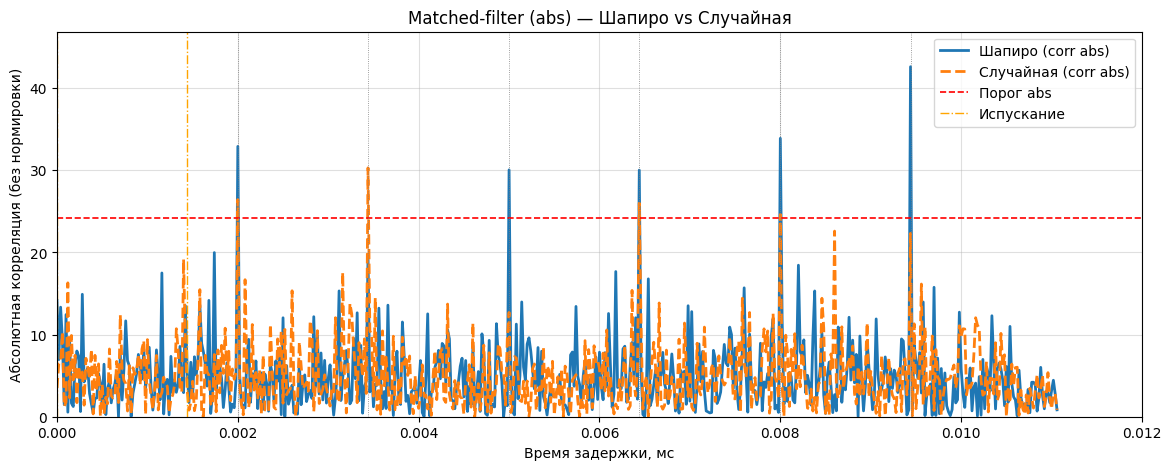

In [118]:
shapiro_file = "../files/shapiro_polynomial_for_radar_experiment.txt"   
random_file = "../files/random_polynomial_for_radar_experiment.txt"     

fs = 50e6                            # Гц
n_pulses = 2
PRI_ms = 0.0008                      # мс
noise_std = 1
targets_ms = [0.002, 0.005, 0.008]   # мс
targets_amp = [0.9, 0.9, 0.9]
seed = 2025

threshold_rel = 0.42   # вычислено оптимальное значение в результате большого числа экспериментов
x_window_ms = 0.012
tol_ms = None          # если None — подбирается автоматически

if __name__ == "__main__":
    exp = Experiment(
        sh_file=shapiro_file,
        rn_file=random_file,
        fs=fs,
        n_pulses=n_pulses,
        PRI_ms=PRI_ms,
        targets_ms=targets_ms,
        targets_amp=targets_amp,
        noise_std=noise_std,
        threshold_rel=threshold_rel,
        x_window_ms=x_window_ms,
        tol_ms=tol_ms,
        seed=seed
    )
    results = exp.run(plot=True)

### Краткий вывод
Из результатов эксперимента видно, что последовательность Шапиро демонстрирует несколько более стабильные результаты по сравнению со случайной последовательностью, однако на основании одного эксперимента нельзя достоверно утверждать, что Шапиро действительно лучше. Явно выделяющихся значений, которые позволили бы сделать однозначный вывод, нет.

## Крупный тест для получения статистических данных

#### Цель эксперимента

В этом эксперименте подбирается оптимальное значения порога детектора *threshold* для последовательностей Шапиро и случайных последовательностей. Порог определяет, при каком уровне корреляции детектор считает сигнал реальной целью, а не шумом.

#### Pfa (Probability of False Alarm)

Pfa — вероятность ложного срабатывания детектора. Вероятность того, что шум будет ошибочно классифицирован как сигнал цели.

Если обозначить стандартное отклонение шума как ($\sigma_C$), то порог детектора *threshold* для заданного Pfa вычисляется как:

$
T = z \cdot \sigma_C, \quad z = \Phi^{-1}(1 - \frac{Pfa}{2})
$

где ($\Phi^{-1}$) — обратная функция распределения нормального закона.


### Подбор оптимального порога

1. Выбирается сетка значений Pfa, например, логарифмическая от 1e-4 до 1e-1.
2. Для каждого Pfa проводится серия прогонов эксперимента с различными случайными параметрами.
3. Для каждого прогона подсчитывается суммарная ошибка детекции (пропуски + ложные срабатывания) для последовательностей Шапиро.
4. Рассчитывается средняя ошибка по всем прогоням для каждого Pfa.
5. Определяется Pfa с минимальной средней ошибкой, и соответствующий ему *threshold* принимается как оптимальный.

### Основной эксперимент после подбора порога

* Используется оптимальный *threshold*, найденный на предыдущем шаге.
* Выполняются многократные прогоны эксперимента с разными случайными параметрами.
* Для каждого прогона собирается статистика: количество правильных детекций, промахов и ложных срабатываний.
* На основе статистики делаются выводы о надежности и эффективности последовательностей Шапиро и случайных последовательностей, а также проверяется, насколько выбранный порог обеспечивает оптимальный баланс между чувствительностью и количеством ложных срабатываний.


## Эксперимент по стресс-тестированию сигналов

### Цель эксперимента

Основная цель эксперимента — подбор оптимального порога детектора *threshold* для последовательностей Шапиро и случайных последовательностей, а также оценка эффективности детекции в условиях шумного канала.

### Pfa (Probability of False Alarm)

Pfa  — вероятность того, что шум будет ошибочно классифицирован как сигнал цели. Pfa задаёт численное значение порога через нормальное распределение шума.

Если обозначить стандартное отклонение шума как $\sigma_C$, то порог детектора для заданного Pfa вычисляется как:

$
T = z \cdot \sigma_C, \quad z = \Phi^{-1}(1 - \frac{Pfa}{2})
$

где $\Phi^{-1}$ — обратная функция распределения нормального закона.


### Подбор оптимального порога

1. Создаётся сетка значений Pfa, например, логарифмическая от 1e-4 до 1e-1.
2. Для каждого значения Pfa выполняются несколько прогонов эксперимента с разными случайными параметрами.
3. Для каждого прогона вычисляется суммарная ошибка детекции:

    $
    E = \text{miss}\cdot\text{sh} + \text{false}\cdot\text{sh}
    $

4. Рассчитывается среднее значение ошибки по всем прогоням для каждого Pfa.
5. Pfa с минимальной средней ошибкой выбирается как оптимальное, и соответствующий порог (T) используется для основной серии экспериментов.

### Основной эксперимент после подбора порога

* Используется подобранный оптимальный порог.
* Выполняются многократные прогоны с разными случайными параметрами.
* Для каждого прогона собираются статистические показатели: количество правильных детекций, промахов и ложных срабатываний.

### Подбор оптимального Pfa

Проводится 200 прогонов для оценки каждого значения Pfa при подборе оптимального порога. Для каждого значения Pfa выполняется 200 прогонов с разными случайными параметрами, чтобы вычислить среднюю ошибку детекции и выбрать Pfa, минимизирующий суммарную ошибку.

В коде используется логарифмическая сетка Pfa от 1e-4 до 1e-1 с 12 

```python
pfa_grid = np.logspace(-4, -1, 12) 
```

Таким образом, каждый из этих 12 значений Pfa оценивается по 200 прогонов с разными случайными параметрами для выбора оптимального порога детектора.


Проводится 100000 прогонов основной серии эксперимента с использованием подобранного порога. Каждый прогон генерирует случайные параметры сигналов и шума, и для него подсчитываются показатели детекции *hits*, промахи *miss* и ложные срабатывания *false*. 

In [119]:
class Tester:
    """
    Класс для стресс-тестирования сигналов Шапиро и случайных последовательностей.

    Проводит симуляцию передачи и приёма сигналов, вычисляет попадания, промахи и ложные
    срабатывания, подбирает оптимальный порог детектора Pfa.

    Attributes
    ----------
    sh_file : str
        Файл с последовательностью Шапиро.
    rn_file : str
        Файл со случайной последовательностью.
    base_seed : int
        Базовый seed для генерации случайных чисел.
    threshold_final : Optional[float]
        Итоговое значение порога после основной серии экспериментов.
    """

    def __init__(self, sh_file: str, rn_file: str, base_seed: int = 2025):
        self.sh_file = sh_file
        self.rn_file = rn_file
        self.base_seed = int(base_seed)
        self.threshold_final: Optional[float] = None
        self.sh_seq = Sequence(self.sh_file)
        self.rn_seq = Sequence(self.rn_file)

    def _sample_params(self, rng: np.random.Generator, override: Optional[Dict] = None) -> Dict:
        """
        Генерация случайных параметров моделирования для одного прогона.

        Parameters
        ----------
        rng : np.random.Generator
            Генератор случайных чисел.
        override : Optional[Dict]
            Переопределение параметров по умолчанию.

        Returns
        -------
        params : dict
            Словарь с параметрами эксперимента.
        """

        # Параметры предыдушего эксперимента для подбора оптимального значения порога
    
        #fs = float(rng.uniform(5e6, 50e6))
        #n_pulses = 2
        #PRI_ms = 0.0008
        #noise_std = 1
        #n_targets = 3
        #targets_ms = [0.002, 0.005, 0.008]
        #targets_amp = [0.9, 1.0, 1.0]

        fs = float(rng.uniform(5e6, 50e6))
        n_pulses = 6
        PRI_ms = float(rng.uniform(0.0005, 0.002))
        noise_std = float(rng.uniform(0.1, 1.5))
        n_targets = 5
        targets_ms = list(rng.uniform(0.001, 0.01, n_targets))
        targets_amp = list(rng.uniform(0.4, 1.0, n_targets))

        params = dict(
            fs=fs, n_pulses=n_pulses, PRI_ms=PRI_ms,
            noise_std=noise_std, targets_ms=targets_ms, targets_amp=targets_amp
        )
        if override is not None:
            params.update(override)
        return params

    @staticmethod
    def compute_sidelobe_max(seq: np.ndarray) -> Tuple[float, np.ndarray]:
        """
        Вычисление максимального бокового лепестка автокорреляции.

        Parameters
        ----------
        seq : np.ndarray
            Последовательность сигнала.

        Returns
        -------
        sidelobe_max : float
            Максимальное значение бокового лепестка.
        R : np.ndarray
            Полная автокорреляция последовательности.
        """
        seq = np.asarray(seq)
        R = np.correlate(seq, seq, mode='full')
        mid = len(R)//2
        sidelobes = np.concatenate([R[:mid], R[mid+1:]])
        return float(np.max(np.abs(sidelobes))), R

    @staticmethod
    def pfa_to_threshold(sigma_C: float, pfa: float) -> Tuple[float, float]:
        """
        Перевод вероятности ложного срабатывания Pfa в порог детектора.

        Parameters
        ----------
        sigma_C : float
            Стандартное отклонение шума.
        pfa : float
            Вероятность ложного срабатывания.

        Returns
        -------
        threshold_abs : float
            Абсолютный порог.
        z : float
            Нормализованное значение порога.
        """
        if pfa <= 0:
            return np.inf, np.inf
        z = norm.ppf(1 - pfa/2)
        return float(z * sigma_C), float(z)

    # Один прогон эксперимента
    def _run_single_adaptive(self, params: Dict, pfa: float, seed: int) -> Dict:
        rng = np.random.default_rng(seed)

        tx_sh = Transmitter(self.sh_seq.seq, params['n_pulses'], params['PRI_ms'], params['fs'])
        tx_rn = Transmitter(self.rn_seq.seq, params['n_pulses'], params['PRI_ms'], params['fs'])

        tx_sh_sig, start_samples_sh, start_times_sh, pulse_duration_ms = tx_sh.generate_tx()
        tx_rn_sig, _, _, _ = tx_rn.generate_tx()

        ch = Channel(params['fs'], seed=seed+2)
        echo_sh_clean, _ = ch.build_echo_clean(tx_sh_sig, params['targets_ms'], params['targets_amp'])
        echo_rn_clean, _ = ch.build_echo_clean(tx_rn_sig, params['targets_ms'], params['targets_amp'])

        L = max(len(echo_sh_clean), len(echo_rn_clean))
        echo_sh_clean = np.pad(echo_sh_clean, (0, L - len(echo_sh_clean)))
        echo_rn_clean = np.pad(echo_rn_clean, (0, L - len(echo_rn_clean)))
        noise = rng.normal(0.0, params['noise_std'], size=L)

        recv_sh = echo_sh_clean + noise
        recv_rn = echo_rn_clean + noise

        recv_obj_sh = Receiver(self.sh_seq.seq, params['fs'])
        recv_obj_rn = Receiver(self.rn_seq.seq, params['fs'])

        lags_sh_ms, corr_sh = recv_obj_sh.matched_filter_abs(recv_sh)
        lags_rn_ms, corr_rn = recv_obj_rn.matched_filter_abs(recv_rn)

        expected_times_per_target = [
            [start_times_sh[k] + t for k in range(params['n_pulses'])]
            for t in params['targets_ms']
        ]
        expected_ms_all = np.array(sorted([t for sub in expected_times_per_target for t in sub]))

        pulse_duration_ms = self.sh_seq.N / params['fs'] * 1000.0
        tol_ms = float(min(pulse_duration_ms/4.0, params['PRI_ms']/3.0, 0.00005))

        mask_exclude = np.zeros_like(lags_sh_ms, dtype=bool)
        mask_valid = lags_sh_ms >= 0
        for t in expected_ms_all:
            mask_exclude |= (np.abs(lags_sh_ms - t) <= (pulse_duration_ms/2.0 + tol_ms))
        exclude_mask = mask_exclude | (~mask_valid)

        # Sigma_C только по Шапиро
        sigma_C = float(np.std(corr_sh[~exclude_mask]))
        threshold_abs, z = self.pfa_to_threshold(sigma_C, pfa)

        peak_times_sh, _, _ = recv_obj_sh.find_peaks_by_threshold(lags_sh_ms, corr_sh, threshold_abs)
        peak_times_rn, _, _ = recv_obj_rn.find_peaks_by_threshold(lags_rn_ms, corr_rn, threshold_abs)

        def classify(found_peaks_ms: List[float]) -> Tuple[int, int]:
            true_count, false_count = 0, 0
            for p in found_peaks_ms:
                if np.any(np.abs(p - expected_ms_all) <= tol_ms):
                    true_count += 1
                else:
                    false_count += 1
            return int(true_count), int(false_count)

        true_sh, false_sh = classify(peak_times_sh)
        true_rn, false_rn = classify(peak_times_rn)

        total_targets = len(params['targets_ms']) * params['n_pulses']
        miss_sh = total_targets - true_sh
        miss_rn = total_targets - true_rn

        smax_sh, _ = self.compute_sidelobe_max(self.sh_seq.seq)
        smax_rn, _ = self.compute_sidelobe_max(self.rn_seq.seq)

        return {
            'hits_sh': true_sh, 'hits_rn': true_rn,
            'false_sh': false_sh, 'false_rn': false_rn,
            'miss_sh': miss_sh, 'miss_rn': miss_rn,
            'total_targets': total_targets,
            'sigma_C': sigma_C, 'threshold_abs': threshold_abs, 'z': z,
            'sidelobe_max_sh': smax_sh, 'sidelobe_max_rn': smax_rn,
            'params': params
        }

    # Подбор оптимального Pfa
    def pick_best_pfa(self, n_eval=40, pfa_grid=None, verbose=True, override_params=None):
        if pfa_grid is None:
            pfa_grid = np.logspace(-4, -1, 12)
        rng = np.random.default_rng(self.base_seed + 1)
        results = []
        for pfa in pfa_grid:
            total_err_sh = 0.0
            for _ in range(n_eval):
                params = self._sample_params(rng, override=override_params)
                res = self._run_single_adaptive(params, pfa, seed=int(rng.integers(0, 100000)))
                total_err_sh += res['miss_sh'] + res['false_sh']
            avg_sh = total_err_sh / n_eval
            results.append((pfa, avg_sh))
            if verbose:
                print(f"pfa={pfa:.1e} -> avg_err_sh={avg_sh:.3f}")
        arr = np.array(results)
        best_idx = np.argmin(arr[:,1])
        best_pfa = float(arr[best_idx,0])
        return best_pfa, results

    # Основной запуск теста
    def run(self, n_runs=200, pick_pfa_eval=40, pfa_grid=None,
            verbose=True, show_stats=True, progress=True,
            override_params=None):

        rng = np.random.default_rng(self.base_seed + 2)
        if verbose:
            print("\n=== Подбор оптимального Pfa (быстрая оценка) ===")
        best_pfa, pfa_scores = self.pick_best_pfa(
            n_eval=pick_pfa_eval, pfa_grid=pfa_grid,
            verbose=verbose, override_params=override_params
        )
        if verbose:
            print(f"\nИспользуем Pfa = {best_pfa:.3e} для основной серии ({n_runs} прогонов)\n")

        stats = []
        iterator = range(n_runs) if not progress else tqdm.tqdm(range(n_runs), desc="tests")
        for i in iterator:
            params = self._sample_params(rng, override=override_params)
            res = self._run_single_adaptive(params, best_pfa, seed=int(rng.integers(0, 100000)))
            stats.append(res)
        df = pd.DataFrame(stats)

        if show_stats:
            n_targets = df['total_targets'].iloc[0]
            hits_sh_mean = df['hits_sh'].mean()
            hits_rn_mean = df['hits_rn'].mean()
            false_sh_mean = df['false_sh'].mean()
            false_rn_mean = df['false_rn'].mean()

            p_sh = hits_sh_mean / n_targets
            p_rn = hits_rn_mean / n_targets
            miss_sh_mean = n_targets - hits_sh_mean
            miss_rn_mean = n_targets - hits_rn_mean
            miss_sh_std = np.sqrt(n_targets * p_sh * (1 - p_sh))
            miss_rn_std = np.sqrt(n_targets * p_rn * (1 - p_rn))

            false_sh_std = df['false_sh'].std()
            false_rn_std = df['false_rn'].std()

            print("\n=== Итоговая статистика (среднее ± std / биномиально для miss) ===")
            print(f"hits_sh: {hits_sh_mean:.3f}")
            print(f"hits_rn: {hits_rn_mean:.3f}")
            print(f"miss_sh: {miss_sh_mean:.3f} ± {miss_sh_std:.3f}")
            print(f"miss_rn: {miss_rn_mean:.3f} ± {miss_rn_std:.3f}")
            print(f"false_sh: {false_sh_mean:.3f} ± {false_sh_std:.3f}")
            print(f"false_rn: {false_rn_mean:.3f} ± {false_rn_std:.3f}")

            threshold_mean = df['threshold_abs'].mean()
            threshold_std = df['threshold_abs'].std()
            threshold_final = float(np.median(df['threshold_abs']))
            threshold_rev = threshold_final / self.sh_seq.N

            print(f"Подобранный порог(абсолютное значение): {threshold_final:.3f}, относительное значение = {threshold_rev:.3f}")
            self.threshold_final = threshold_final

        return df, best_pfa, pfa_scores

In [120]:
tester = Tester(sh_file=shapiro_file, rn_file=random_file, base_seed=seed)
df, best_pfa, _ = tester.run(n_runs=100000, pick_pfa_eval=200, verbose=False)

tests: 100%|██████████| 100000/100000 [07:32<00:00, 220.77it/s]



=== Итоговая статистика (среднее ± std / биномиально для miss) ===
hits_sh: 25.045
hits_rn: 23.577
miss_sh: 4.955 ± 2.034
miss_rn: 6.423 ± 2.247
false_sh: 33.616 ± 19.459
false_rn: 49.945 ± 25.389
Подобранный порог(абсолютное значение): 10.584, относительное значение = 0.331


1. **Детекция целей**: Последовательности Шапиро показывают немного большее количество правильных детекций hits_sh > hits_rn

2. **Пропущенные цели (*miss*)**: Для последовательностей Шапиро среднее количество пропущенных целей меньше, чем для случайных последовательностей.

3. **Ложные срабатывания (*false*)**: Последовательности Шапиро имеют значительно меньше ложных срабатываний по сравнению со случайными последовательностями, что демонстрирует лучшую устойчивость к шуму. Предположительно это связано с лучшими автокорреляционными свойствами, как и ожидалось

4. **Подобранный порог**: Абсолютный порог 10.584 был получен на основе серии прогонов с разными значениями Pfa, минимизируя суммарную ошибку. Относительное значение 0.331 показывает, что порог составляет примерно треть стандартного отклонения сигнала

#### Вывод
Последовательности Шапиро действительно имеют лучшие свойтва в таком эксперименте.